In [6]:
import numpy as np
import chaospy
from scipy.stats import norm 

In [ ]:
def generate_draws(n=3, d=2, rule="random"):
    '''Generate draws for income and asset returns
    Parameters:
        n: number of draws (scalar)
        d: number of dimensions (scalar)
        rule: quadrature rule for income and asset returns
            (str) "legendre", "random", "halton", "sobol"
    Returns:
        w: weights for quadrature (1 x N) or weight w=1/n for random draws (scalar)
        x: draws for income and asset returns (d x n)
        for muldimensional case, quadrature nodes are tensor product of 1D nodes
        with int(n**(1/d)) nodes in each dimension
    '''
    distribution = chaospy.Iid(chaospy.Uniform(0, 1), d)
    if rule == 'legendre':
        order = int(n**(1/d)) - 1
        x, w = chaospy.generate_quadrature(order, distribution, rule=rule, sparse=False)
    else:
        x = chaospy.generate_samples(n, domain=d, rule=rule)  
        w = np.full((1, x.shape[1]), 1/x.shape[1])  # Equal weight for Monte Carlo
    return w, x

import numpy as np
from scipy.stats import norm  
def inverse_multinormal(u, mu=None, Sigma=None):
    '''Inverse transform sampling for multivariate normal
    Parameters:
        u: uniform random numbers (d x n)
        mu: mean vector (d x 1)
        Sigma: covariance matrix (d x d)
    Returns:
        x: draws from multivariate normal (d x n) with x~N(mu, Sigma)
    '''
    x = norm.ppf(u)  # inverse cdf of standard normal
    if Sigma is not None:
        L = np.linalg.cholesky(Sigma)  
        x = L @ x # 
    if mu is not None:
        mu = np.array(mu).reshape(-1,1)
        x += mu
    return x

def build_sigma(sigma = [1,.1], c=0): 
    '''build d-dimensional (dxd) covariance matrix Sigma with correlation c and std deviations sigma
    Parameters:
        sigma: list of std deviations for d random variables
        c: correlation coefficient between random variables (default=0) can only create negaive correlation for d=2'''
    sigma=np.array(sigma).reshape(-1,1); 
    d=len(sigma);
    if (c<0.0) and not (d==2):
        raise RuntimeError('build_sigma can only create negaive correlation for d=2')
    corr=(1-c)*np.identity(d) + c*np.ones((d,d)); # correlation martrix 
    Sigma=sigma*corr*sigma.T # Covariance matrix  
    return Sigma

In [15]:
beta = 0.96
gamma = 2
mu_y = 0
sigma_y = 0.1

mu_R= 1+ np.linspace(0.02,0.04, 2)
sigma = np.linspace(0.05, 0.15, 2)
Sigma_R = build_sigma(sigma, c=0)
rho_y = np.zeros((len(mu_R),1))
bnd_x = [0.1, 10]
n_x = 50
n_rand = 100
N = len(mu_R)
n_choices = N + 1
x0 = np.linspace(bnd_x[0], bnd_x[1], n_x).reshape(n_x, 1)
mu_R = np.array(mu_R).reshape(N, 1)
mu = np.vstack([[mu_y], mu_R])
sigma = np.block([
            [sigma_y**2, rho_y.T @ Sigma_R],
            [Sigma_R @ rho_y, Sigma_R]
        ])  

w, u = generate_draws(n_rand, N+1, rule="random")
x = inverse_multinormal(u, mu, sigma)
y = np.exp(x[0,:]).reshape(1,-1)
R = x[1:,:]

In [17]:
import numpy as np
from scipy.stats import norm
import chaospy

# ------------------------------------------------------------
# 0.  INPUT PARAMETERS  (edit at will)
# ------------------------------------------------------------
mu_y    = 0.0                     # mean of ln Y
sigma_y = 0.20                    # std-dev of ln Y

mu_R    = np.array([1.05, 1.08])  # means of risky returns (gross)
sigma_R = np.array([0.15, 0.25])  # std-devs
c_assets = 0                      # set ≠0 for asset-to-asset corr.

# ------------------------------------------------------------
# 1.  BUILD JOINT μ  AND  Σ
#     shape: μ  → ((N+1),1)   Σ → ((N+1),(N+1))
# ------------------------------------------------------------
N        = mu_R.size
mu       = np.vstack(([mu_y], mu_R.reshape(-1, 1)))        # (N+1,1)

Sigma_R  = build_sigma(sigma=sigma_R, c=c_assets)          # asset block
Sigma    = np.block([
    [sigma_y**2,           np.zeros((1, N))],              # top row
    [np.zeros((N, 1)),     Sigma_R          ]              # bottom
])

# ------------------------------------------------------------
# 2.  DRAW UNIFORMS  →  MULTIVARIATE NORMAL
# ------------------------------------------------------------
def get_draws(n_rand, *, rule="random"):
    """
    Returns:
        w : (1,n_rand)      equal weights 1/n_rand
        y : (1,n_rand)      labour income levels   Y_{t+1}
        R : (N,n_rand)      risky-asset returns    R_{i,t+1}
    """
    w, u = generate_draws(n_rand, N+1, rule=rule)          # step (a)
    x    = inverse_multinormal(u, mu=mu, Sigma=Sigma)      # step (b)
    
    y = np.exp(x[0, :]).reshape(1, -1)   # ln Y  →  Y         (c₁)
    R = x[1:, :]                         # risky returns      (c₂)
    return w, y, R


In [18]:
w, y_draws, R_draws = get_draws(n_rand=1_000)   # or any n_rand you like


In [19]:
np.shape(w), np.shape(y_draws), np.shape(R_draws)

((1, 1000), (1, 1000), (2, 1000))

In [23]:
def portfolio_return(w, R):
    """
    Compute the portfolio’s gross return for each scenario.

    Parameters
    ----------
    w : (N,) 1-D array-like
        Portfolio weights on the N risky assets.  Must sum to 1.
    R : (N, n_draws) array-like
        Matrix of gross returns for the same N assets across n_draws
        Monte-Carlo / quadrature scenarios.

    Returns
    -------
    R_p : (1, n_draws) ndarray
        Row vector of portfolio returns, one per column of R.
    """
    w = np.asarray(w).reshape(-1, 1)        # (N,1) column vector
    assert np.isclose(w.sum(), 1.0), "Weights must sum to 1."

    R_p = w.T @ R                           # (1,N)·(N,n_draws) → (1,n_draws)
    return R_p


In [24]:
def state_transition_cash(x, c, w, R, y):
    """
    Cash-on-hand transition with explicit consumption.

    Parameters
    ----------
    x : float
        Beginning-of-period cash/wealth x_t (after labour income from t−1 has arrived).
    c : float
        Consumption chosen at t.
    w : (N,) 1-D array-like
        Portfolio weights in the N risky assets, summing to 1.
    R : (N, n_draws) array-like
        Matrix of gross returns for the assets across n_draws scenarios.
    y : (1, n_draws) array-like
        Row vector of next-period labour income draws y_{t+1}.

    Returns
    -------
    x_next : (1, n_draws) ndarray
        Cash-on-hand next period.
    w_next : (N, n_draws) ndarray
        End-of-period portfolio weights (needed if you track them).
    """
    # ---- enforce shapes -------------------------------------------------
    w = np.asarray(w).reshape(-1, 1)          # (N,1) column
    R = np.asarray(R)
    y = np.asarray(y)
    assert np.isclose(w.sum(), 1.0), "Weights must sum to 1."
    assert c <= x, "Consumption can’t exceed cash-on-hand."

    # ---- portfolio return for each scenario -----------------------------
    R_port = w.T @ R                          # (1, n_draws)

    # ---- next-period cash-on-hand ---------------------------------------
    investable = x - c                        # x_t − c_t
    x_next = investable * R_port + y          # (1, n_draws)

    # ---- next-period portfolio weights ----------------------------------
    w_next = (w * R) / R_port                # (N, n_draws)

    return x_next, w_next


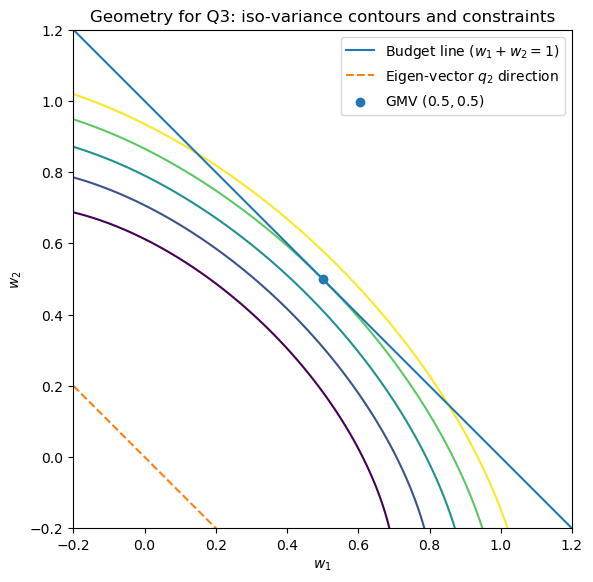

In [46]:
import numpy as np
import matplotlib.pyplot as plt

# Example covariance parameters (a > b > 0)
a, b = 0.04, 0.02  # feel free to change these

# Create a grid of weights
w1 = np.linspace(-0.2, 1.2, 400)
w2 = np.linspace(-0.2, 1.2, 400)
W1, W2 = np.meshgrid(w1, w2)

# Portfolio variance σ² = a(w1² + w2²) + 2b w1 w2
Var = a * (W1**2 + W2**2) + 2 * b * W1 * W2

# Plot iso‑variance contours, budget line, eigen‑vector line, GMV point
plt.figure(figsize=(6, 6))

# A few contour levels around the GMV variance
levels = [0.015, 0.02, 0.025, 0.03, 0.035]
plt.contour(W1, W2, Var, levels=levels)

# Budget line w1 + w2 = 1
w1_line = np.linspace(-0.2, 1.2, 200)
plt.plot(w1_line, 1 - w1_line, label="Budget line ($w_1+w_2=1$)")

# Eigen‑vector (smallest eigenvalue) direction w2 = -w1
plt.plot(w1_line, -w1_line, linestyle="--", label="Eigen‑vector $q_2$ direction")

# GMV point (½, ½)
plt.scatter([0.5], [0.5], marker="o", label="GMV $(0.5,0.5)$")

plt.xlabel("$w_1$")
plt.ylabel("$w_2$")
plt.title("Geometry for Q3: iso‑variance contours and constraints")
plt.legend()
plt.xlim(-0.2, 1.2)
plt.ylim(-0.2, 1.2)
plt.gca().set_aspect("equal")
plt.tight_layout()



In [26]:
W_min, W_max, N_W = 0.0, 20.0, 200
W_grid = np.linspace(W_min, W_max, N_W)          # shape (N_W,)
tau = 0.01

In [ ]:
# ---------- 1. utility -------------------------------------------------
def u(c):
    eps = 1e-10
    if gamma == 1.0:
        return np.log(c + eps)
    return ((c + eps)**(1-gamma) - 1)/(1-gamma)

# ---------- 2. state grids --------------------------------------------
W_grid       = np.linspace(W_min, W_max, N_W)      # cash-on-hand
Wshare_grid  = np.linspace(0, 1, 11)               # share in asset 1
c_frac_grid  = np.linspace(0.00, 0.95, 15)         # c/x ratios

N_W    = W_grid.size
N_WSH  = Wshare_grid.size
N_C    = c_frac_grid.size

# ---------- 3. storage -------------------------------------------------
V      = np.zeros((T+1, N_W, N_WSH))
pol_c  = np.zeros_like(V)
pol_w1 = np.zeros_like(V)

# ---------- 4. terminal condition -------------------------------------
for iW, x in enumerate(W_grid):
    for iWS, w1 in enumerate(Wshare_grid):
        V[T, iW, iWS] = u(x)          # consume everything at T

# ---------- 5. pre-draw shocks (income & returns) ----------------------
n_draws = 9
w_q, y_draws, R_draws = get_draws(n_rand=n_draws)   # y:(1,n)  R:(2,n)

# ---------- 6. backward induction -------------------------------------
for t in range(T-1, -1, -1):
    for iW, x in enumerate(W_grid):
        for iWS, w_prev in enumerate(Wshare_grid):

            best_val = -np.inf
            best_c   = 0.0
            best_w1  = w_prev

            for frac in c_frac_grid:               # consumption choice
                c = frac * x
                for w1 in Wshare_grid:             # new portfolio share
                    delta   = w1 - w_prev
                    cost    = tau * x * abs(delta)
                    invest  = x - c - cost
                    if invest <= 0:                # infeasible
                        continue

                    # Build weight vector for two risky assets
                    w_vec = np.array([w1, 1-w1]).reshape(2, 1)

                    # Transition (cash & weights) for every draw
                    x_next, w_next = state_transition_cash(
                                        x, c, w_vec,
                                        R_draws, y_draws)

                    # locate nearest grid nodes for x_next and w1_next
                    idx_x = np.clip(np.searchsorted(W_grid, x_next) - 1,
                                    0, N_W-1)
                    w1_next = w_next[0, :]
                    idx_w = np.clip(np.searchsorted(Wshare_grid, w1_next) - 1,
                                    0, N_WSH-1)

                    V_tp1 = V[t+1, idx_x, idx_w]
                    EV = np.sum(w_q.flatten() * V_tp1)      # expectation

                    val = u(c) + beta * EV
                    if val > best_val:
                        best_val, best_c, best_w1 = val, c, w1

            # store optimal value & policies
            V[t, iW, iWS]     = best_val
            pol_c[t, iW, iWS] = best_c
            pol_w1[t, iW, iWS]= best_w1

print("Value-function iteration completed.")

Value-function iteration completed.


In [41]:
counter = 0
while (counter < 1000000000):
  counter+=1

print(counter)

1000000000


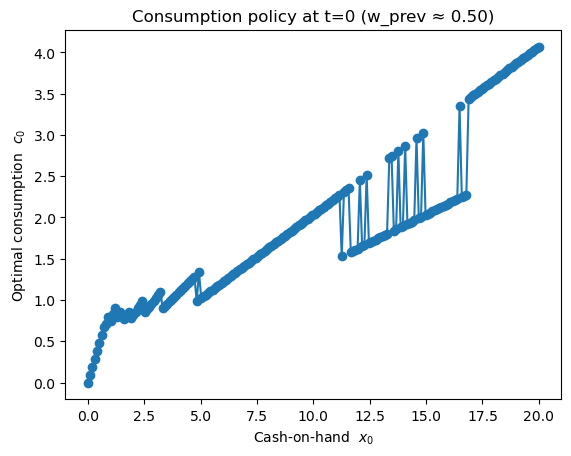

In [37]:
import matplotlib.pyplot as plt

# pick the middle weight grid index as an example
iWS_mid = N_WSH//2          # e.g. w_prev = 0.5 if Wshare_grid ∈ [0,1]

plt.plot(W_grid,
         pol_c[0, :, iWS_mid],
         marker="o")
plt.xlabel("Cash-on-hand  $x_0$")
plt.ylabel("Optimal consumption  $c_0$")
plt.title("Consumption policy at t=0 (w_prev ≈ {:.2f})".format(Wshare_grid[iWS_mid]))
plt.show()


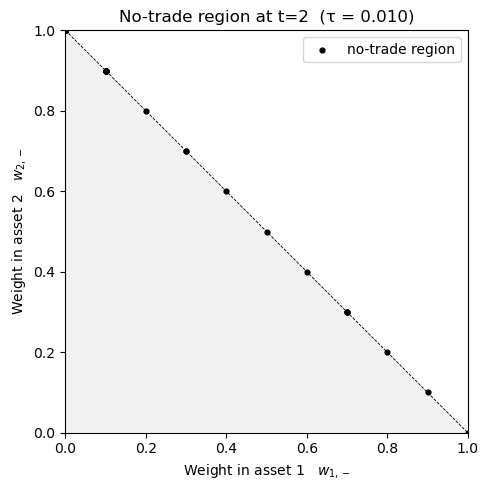

In [45]:
# --- choose which period to inspect -----------------------------------
t_view = 2                # e.g. t = 0

tol = 1e-4                # tolerance for “no trade”

# ----------------------------------------------------------------------
# Boolean mask: True ⇢ no trade at (x, w1_prev)
# ----------------------------------------------------------------------
no_trade = np.abs(pol_w1[t_view] - Wshare_grid[None, :]) < tol
#            shape = (N_W , N_WSH)

# ----------------------------------------------------------------------
# Build coordinates in (w1_prev, w2_prev) space
# ----------------------------------------------------------------------
w1_prev = Wshare_grid[None, :]                  # (1, N_WSH)
w2_prev = 1.0 - w1_prev                         # (1, N_WSH)

W1, W2 = np.broadcast_to(w1_prev, no_trade.shape), \
         np.broadcast_to(w2_prev, no_trade.shape)

# ----------------------------------------------------------------------
# Scatter plot on the simplex w1 + w2 ≤ 1
# (Here they always sum to 1, so points lie on the diagonal.)
# ----------------------------------------------------------------------
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(5.5,5))
ax.set_aspect('equal')
ax.set_xlabel("Weight in asset 1   $w_{1,-}$")
ax.set_ylabel("Weight in asset 2   $w_{2,-}$")
ax.set_xlim(0,1);  ax.set_ylim(0,1)

# draw simplex boundary
ax.fill([0,1,0],[0,0,1], color='lightgrey', alpha=0.3, edgecolor='none')

# all feasible states (light markers)
ax.scatter(W1.flatten(), W2.flatten(),
           s=6, facecolors='white', edgecolors='grey', linewidths=0.3, alpha=0.4)

# overlay the no-trade states (solid black)
ax.scatter(W1[no_trade], W2[no_trade],
           s=12, color='black', label='no-trade region')

ax.plot([0,1],[1,0],'k--', lw=0.6)          # cash-free diagonal (optional)
ax.legend()
ax.set_title(f"No-trade region at t={t_view}  (τ = {tau:.3f})")
plt.tight_layout()
plt.show()
